# Recommandation de formations — démarche CRISP-DM

## 1 — Compréhension du besoin

## 2 — Compréhension des données

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

ALEA = 42          # graine fixee : tous les resultats de ce notebook sont reproductibles
np.random.seed(ALEA)

In [2]:
# La base servie par l'application.
URL_BASE = "mysql+pymysql://root:@localhost:3306/pidev_formation?charset=utf8mb4"

# Exactement la requête du service (main.py) : description_detaillee et non
# description, cette dernière n'étant que le résumé court affiché sur la carte. Un
# TF-IDF sur des textes tronqués comparerait des débuts de phrase.
SQL_FORMATIONS = """
    SELECT f.id                              AS formation_id,
           f.titre                           AS titre,
           COALESCE(c.nom, 'Sans catégorie') AS categorie,
           COALESCE(f.niveau, 'DEBUTANT')    AS niveau,
           COALESCE(NULLIF(f.description_detaillee, ''), f.description, '') AS description
    FROM formations f
    LEFT JOIN categories c ON c.id = f.categorie_id
"""
SQL_INSCRIPTIONS = "SELECT user_id, formation_id FROM inscriptions"

moteur = create_engine(URL_BASE)
formations = pd.read_sql(SQL_FORMATIONS, moteur)
inscriptions = pd.read_sql(SQL_INSCRIPTIONS, moteur).drop_duplicates()

print(f"{len(formations):>6} formations")
print(f"{inscriptions['user_id'].nunique():>6} apprenants")
print(f"{len(inscriptions):>6} inscriptions")
formations.head()

    59 formations
   201 apprenants
  1625 inscriptions


,formation_id,titre,categorie,niveau,description
0,1,Spring Boot,IT,INTERMEDIAIRE,Cette formation couvre la construction d'APIs ...
1,101,Principes UX,Design UX/UI,AVANCE,Formation avancé en Principes UX : conception ...
2,102,Ansible,DevOps,AVANCE,"Formation avancé en Ansible : automatisation, ..."
3,103,VPN et pare-feu,Réseaux,INTERMEDIAIRE,Formation intermédiaire en VPN et pare-feu : i...
4,104,Pandas,Data Science,DEBUTANT,Formation débutant en Pandas : analyse de donn...


### 2.1 — Densité de la matrice

In [87]:
n_app = inscriptions["user_id"].nunique()
n_for = len(formations)
densite = len(inscriptions) / (n_app * n_for)

par_apprenant = inscriptions.groupby("user_id").size()
par_formation = inscriptions.groupby("formation_id").size()

print(f"Densite de la matrice        : {densite:.1%}")
print(f"Inscriptions par apprenant   : moyenne {par_apprenant.mean():.1f}, "
      f"mediane {par_apprenant.median():.0f}, min {par_apprenant.min()}, max {par_apprenant.max()}")
print(f"Inscriptions par formation   : moyenne {par_formation.mean():.1f}, "
      f"min {par_formation.min()}, max {par_formation.max()}")

Densite de la matrice        : 13.7%
Inscriptions par apprenant   : moyenne 8.1, mediane 8, min 2, max 23
Inscriptions par formation   : moyenne 28.0, min 16, max 43


### 2.2 — La popularité est-elle concentrée ?

Part des 5 formations les plus suivies : 12.6%


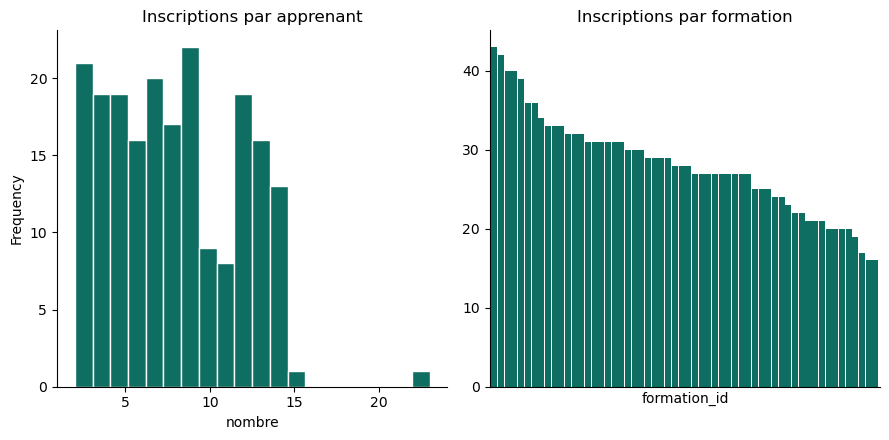

In [4]:
top5 = par_formation.sort_values(ascending=False).head(5)
part_top5 = top5.sum() / len(inscriptions)
print(f"Part des 5 formations les plus suivies : {part_top5:.1%}")

fig, ax = plt.subplots(1, 2)
par_apprenant.plot.hist(bins=20, ax=ax[0], color="#0F6E62", edgecolor="white")
ax[0].set_title("Inscriptions par apprenant"); ax[0].set_xlabel("nombre")
par_formation.sort_values(ascending=False).plot.bar(ax=ax[1], color="#0F6E62", width=0.9)
ax[1].set_title("Inscriptions par formation"); ax[1].set_xticks([])
plt.tight_layout(); plt.show()

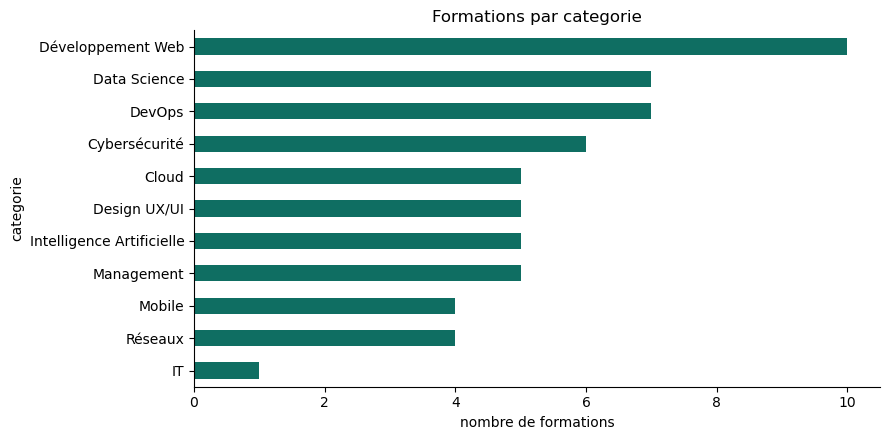

categorie
Développement Web            10
Data Science                  7
DevOps                        7
Cybersécurité                 6
Cloud                         5
Design UX/UI                  5
Intelligence Artificielle     5
Management                    5
Mobile                        4
Réseaux                       4
IT                            1
dtype: int64

In [5]:
repartition = formations.groupby("categorie").size().sort_values(ascending=False)
repartition.plot.barh(color="#0F6E62")
plt.title("Formations par categorie"); plt.xlabel("nombre de formations")
plt.gca().invert_yaxis(); plt.tight_layout(); plt.show()
repartition

## 3 — Préparation des données

### 3.1 — Le texte des formations (pour le contenu)

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

texte = (formations["titre"] + " " + formations["categorie"] + " "
         + formations["niveau"] + " " + formations["description"])

vectoriseur = TfidfVectorizer(lowercase=True, strip_accents="unicode", min_df=1)
X_texte = vectoriseur.fit_transform(texte)

print(f"Matrice TF-IDF : {X_texte.shape[0]} formations x {X_texte.shape[1]} termes")
print("Exemple de termes :", ", ".join(vectoriseur.get_feature_names_out()[:12]))

Matrice TF-IDF : 59 formations x 166 termes
Exemple de termes : 10, accessibilite, accessibles, actions, administration, agile, agiles, analyse, analytique, android, angular, ansible


### 3.2 — La matrice apprenant × formation (pour le collaboratif)

In [7]:
matrice = (inscriptions.assign(v=1)
           .pivot_table(index="user_id", columns="formation_id", values="v", fill_value=0)
           .reindex(columns=formations["formation_id"], fill_value=0))
print("Matrice apprenant x formation :", matrice.shape)
matrice.iloc[:5, :8]

Matrice apprenant x formation : (201, 59)


formation_id,1,101,102,103,104,105,106,107
user_id,,,,,,,,
19,0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1001,0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
1002,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1003,0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
1004,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### 3.3 — Le profil d'un apprenant (pour la segmentation)

In [8]:
details = inscriptions.merge(formations[["formation_id", "categorie", "niveau"]],
                             on="formation_id")

profils = (pd.crosstab(details["user_id"], details["categorie"], normalize="index")
             .add_prefix("cat_")
             .join(pd.crosstab(details["user_id"], details["niveau"],
                               normalize="index").add_prefix("niv_"))
             .fillna(0.0))

print(f"Profils : {profils.shape[0]} apprenants x {profils.shape[1]} variables")
profils.head(3).round(2)

Profils : 201 apprenants x 13 variables


,cat_Cloud,cat_Cybersécurité,cat_Data Science,cat_Design UX/UI,cat_DevOps,cat_Développement Web,cat_Intelligence Artificielle,cat_Management,cat_Mobile,cat_Réseaux,niv_AVANCE,niv_DEBUTANT,niv_INTERMEDIAIRE
user_id,,,,,,,,,,,,,
19,0.13,0.04,0.09,0.04,0.22,0.22,0.09,0.09,0.00,0.09,0.22,0.43,0.35
1001,0.07,0.40,0.00,0.13,0.00,0.07,0.00,0.00,0.07,0.27,0.20,0.27,0.53
1002,0.00,0.33,0.00,0.00,0.11,0.11,0.00,0.44,0.00,0.00,0.22,0.56,0.22


## 4 — Modélisation

### 4.1 — Similarité de contenu (TF-IDF + cosinus)

In [9]:
from sklearn.metrics.pairwise import cosine_similarity

sim_formations = pd.DataFrame(cosine_similarity(X_texte),
                              index=formations["formation_id"],
                              columns=formations["formation_id"])

exemple = formations.iloc[0]
proches = sim_formations.loc[exemple["formation_id"]].drop(exemple["formation_id"]).nlargest(5)
print(f"Formations proches de « {exemple['titre']} » ({exemple['categorie']}) :\n")
for fid, score in proches.items():
    ligne = formations.set_index("formation_id").loc[fid]
    print(f"  {score:.3f}  {ligne['titre']}  ({ligne['categorie']})")

Formations proches de « Spring Boot » (IT) :

  0.349  Spring Boot  (Développement Web)
  0.204  Python pour la data  (Data Science)
  0.144  Android avec Kotlin  (Mobile)
  0.130  CI/CD avec Jenkins  (DevOps)
  0.124  iOS avec Swift  (Mobile)


### 4.2 — Similarité entre apprenants (collaboratif)

In [10]:
sim_apprenants = pd.DataFrame(cosine_similarity(matrice.values),
                              index=matrice.index, columns=matrice.index)
np.fill_diagonal(sim_apprenants.values, 0.0)
print("Similarite apprenant x apprenant :", sim_apprenants.shape)

Similarite apprenant x apprenant : (201, 201)


### 4.3 — Segmentation K-Means, avec k choisi par le score de silhouette

  File "C:\Users\LENOVO\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\LENOVO\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\LENOVO\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\LENOVO\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


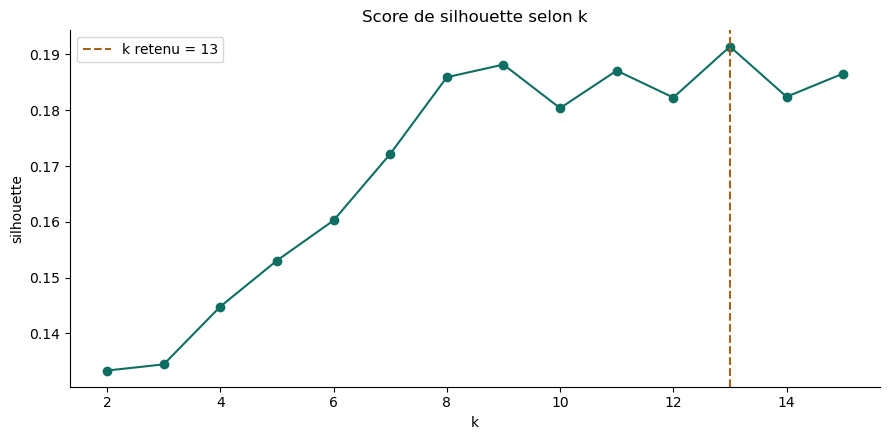

k retenu : 13  (silhouette = 0.191)


In [11]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X_profils = profils.values
k_max = min(15, len(X_profils) - 1)

scores = {}
for k in range(2, k_max + 1):
    km = KMeans(n_clusters=k, random_state=ALEA, n_init=10).fit(X_profils)
    scores[k] = silhouette_score(X_profils, km.labels_)

k_optimal = max(scores, key=scores.get)
kmeans = KMeans(n_clusters=k_optimal, random_state=ALEA, n_init=10).fit(X_profils)

pd.Series(scores).plot(marker="o", color="#0F6E62")
plt.axvline(k_optimal, color="#A6641A", linestyle="--", label=f"k retenu = {k_optimal}")
plt.title("Score de silhouette selon k"); plt.xlabel("k"); plt.ylabel("silhouette")
plt.legend(); plt.tight_layout(); plt.show()

print(f"k retenu : {k_optimal}  (silhouette = {scores[k_optimal]:.3f})")

### 4.4 — ACP, pour voir la structure

7 composantes sont necessaires pour atteindre 80 % de la variance


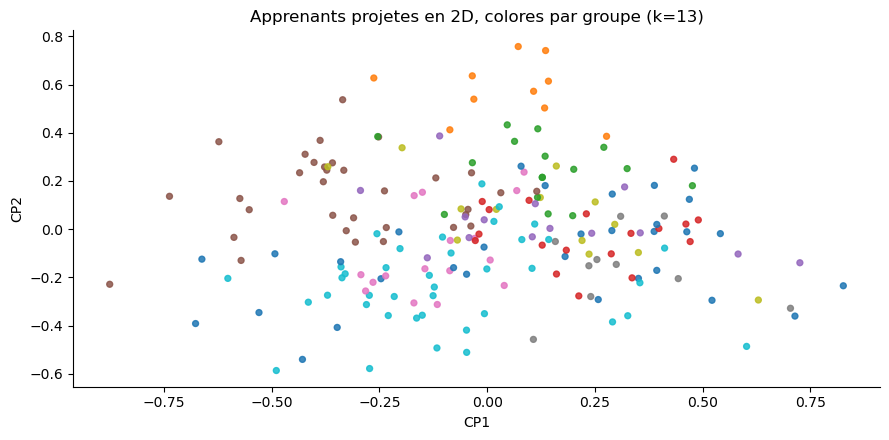

In [12]:
from sklearn.decomposition import PCA

acp_complete = PCA(random_state=ALEA).fit(X_profils)
cumul = np.cumsum(acp_complete.explained_variance_ratio_)
n_80 = int(np.argmax(cumul >= 0.80) + 1)
print(f"{n_80} composantes sont necessaires pour atteindre 80 % de la variance")

proj = PCA(n_components=2, random_state=ALEA).fit_transform(X_profils)
plt.scatter(proj[:, 0], proj[:, 1], c=kmeans.labels_, cmap="tab10", s=18, alpha=0.85)
plt.title(f"Apprenants projetes en 2D, colores par groupe (k={k_optimal})")
plt.xlabel("CP1"); plt.ylabel("CP2"); plt.tight_layout(); plt.show()

### 4.5 — La recommandation hybride

In [13]:
POIDS_CONTENU = 0.5
N_VOISINS = 20

def normaliser(s):
    """Ramène entre 0 et 1 : les deux scores n'ont pas la même échelle."""
    etendue = s.max() - s.min()
    return (s - s.min()) / etendue if etendue > 0 else s * 0.0

def scores_contenu(vues, sim):
    """Ressemblance moyenne avec ce que l'apprenant suit déjà."""
    return normaliser(sim.loc[vues].mean(axis=0))

def scores_collaboratif(user_id, mat, sim):
    """Ce que suivent les apprenants les plus proches. None s'il n'en a aucun."""
    if user_id not in sim.index:
        return None
    voisins = sim.loc[user_id].nlargest(N_VOISINS)
    voisins = voisins[voisins > 0]
    if voisins.empty:
        return None
    return normaliser(mat.loc[voisins.index].mul(voisins.values, axis=0).sum())

def hybride(s_contenu, s_collab):
    """Les deux scores combinés à parts égales ; le contenu seul s'il n'y a pas de voisins."""
    if s_collab is None:
        return s_contenu
    return POIDS_CONTENU * s_contenu + (1 - POIDS_CONTENU) * s_collab

## 5 — Évaluation

In [14]:
K = 5
MIN_INSCRIPTIONS = 4
rng = np.random.RandomState(ALEA)

# Decoupage par apprenant : 20 % des inscriptions passent en test.
test_par_apprenant, lignes_entrainement = {}, []
for uid, groupe in inscriptions.groupby("user_id"):
    items = groupe["formation_id"].tolist()
    # En dessous de 4 inscriptions, retirer 20 % ne laisserait presque rien pour
    # apprendre : ces apprenants restent entièrement dans l'entraînement.
    if len(items) >= MIN_INSCRIPTIONS:
        rng.shuffle(items)
        n_test = max(1, int(round(0.2 * len(items))))
        test_par_apprenant[uid] = set(items[:n_test])
        gardes = items[n_test:]
    else:
        gardes = items
    lignes_entrainement += [{"user_id": uid, "formation_id": f} for f in gardes]

entrainement = pd.DataFrame(lignes_entrainement)
print(f"{len(test_par_apprenant)} apprenants evalues")
print(f"{len(entrainement)} inscriptions d'entrainement, "
      f"{sum(len(v) for v in test_par_apprenant.values())} de test")
print(f"Taille moyenne du jeu de test : "
      f"{np.mean([len(v) for v in test_par_apprenant.values()]):.2f} formations par apprenant")

180 apprenants evalues
1306 inscriptions d'entrainement, 319 de test
Taille moyenne du jeu de test : 1.77 formations par apprenant


In [15]:
# Tout est reconstruit sur l'entraînement SEUL : c'est ce qui empêche la réponse de
# fuiter dans l'apprentissage. Le texte des formations, lui, n'est pas concerné —
# seules les inscriptions ont été découpées.
mat_tr = (entrainement.assign(v=1)
          .pivot_table(index="user_id", columns="formation_id", values="v", fill_value=0)
          .reindex(columns=formations["formation_id"], fill_value=0))

sim_app_tr = pd.DataFrame(cosine_similarity(mat_tr.values),
                          index=mat_tr.index, columns=mat_tr.index)
np.fill_diagonal(sim_app_tr.values, 0.0)

popularite_tr = mat_tr.sum().sort_values(ascending=False)

def recommander_tr(uid, methode):
    """Les K suggestions selon l'approche demandée, pour comparer les trois."""
    vues = mat_tr.columns[mat_tr.loc[uid] > 0].tolist()
    if methode == "populaire":
        return popularite_tr.drop(index=vues).nlargest(K).index.tolist()
    s_c = scores_contenu(vues, sim_formations)
    if methode == "contenu":
        total = s_c
    else:
        total = hybride(s_c, scores_collaboratif(uid, mat_tr, sim_app_tr))
    return total.drop(index=vues).nlargest(K).index.tolist()

def evaluer(methode):
    """Moyenne de la précision@5 et du rappel@5 sur tous les apprenants évalués.

    précision = bonnes suggestions / 5 proposées
    rappel    = bonnes suggestions / formations réellement suivies
    """
    precisions, rappels = [], []
    for uid, attendu in test_par_apprenant.items():
        if uid not in mat_tr.index:
            continue
        proposes = recommander_tr(uid, methode)
        touches = len(set(proposes) & attendu)   # suggestions effectivement suivies
        precisions.append(touches / K)
        rappels.append(touches / len(attendu))
    return np.mean(precisions), np.mean(rappels)

resultats = pd.DataFrame(
    [(m,) + evaluer(m) for m in ["populaire", "contenu", "hybride"]],
    columns=["methode", "precision@5", "rappel@5"]).set_index("methode")

resultats["gain vs populaire"] = (resultats["precision@5"]
                                  / resultats.loc["populaire", "precision@5"]).round(2)
resultats.round(4)

,precision@5,rappel@5,gain vs populaire
methode,,,
populaire,0.0489,0.1456,1.00
contenu,0.2156,0.6169,4.41
hybride,0.2267,0.6372,4.64


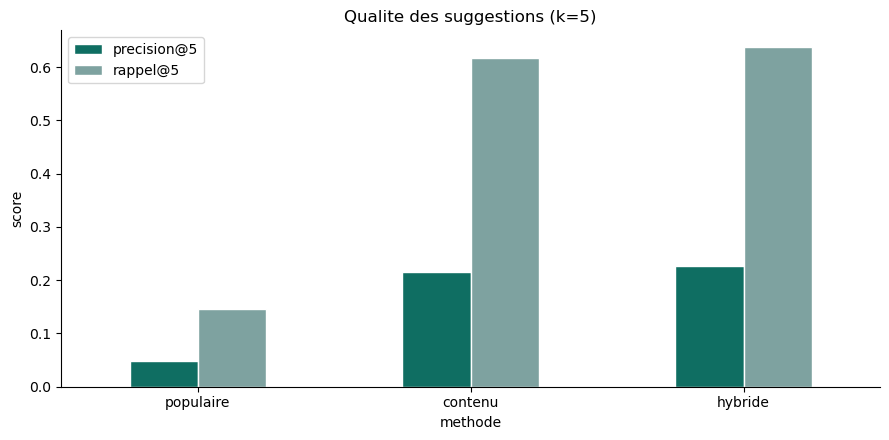

Plafond theorique de la precision@5 : 35.4%
  (un apprenant dont le jeu de test contient moins de 5 formations
   ne peut pas obtenir une precision de 100 %)


In [16]:
ax = resultats[["precision@5", "rappel@5"]].plot.bar(
    color=["#0F6E62", "#7EA2A0"], edgecolor="white", rot=0)
ax.set_title(f"Qualite des suggestions (k={K})"); ax.set_ylabel("score")
ax.legend(loc="upper left"); plt.tight_layout(); plt.show()

plafond = np.mean([min(len(v), K) for v in test_par_apprenant.values()]) / K
print(f"Plafond theorique de la precision@{K} : {plafond:.1%}")
print("  (un apprenant dont le jeu de test contient moins de 5 formations")
print("   ne peut pas obtenir une precision de 100 %)")

### 5.2 — Les groupes retrouvent-ils quelque chose de réel ?

In [17]:
colonnes_cat = [c for c in profils.columns if c.startswith("cat_")]
dominante = profils[colonnes_cat].idxmax(axis=1).str.replace("cat_", "", regex=False)

table = pd.crosstab(pd.Series(kmeans.labels_, index=profils.index, name="groupe"), dominante)
purete = table.max(axis=1).sum() / table.values.sum()
categories_retrouvees = table.idxmax(axis=1).nunique()

print(f"Purete des groupes                    : {purete:.1%}")
print(f"Categories distinctes retrouvees      : {categories_retrouvees} sur {dominante.nunique()}")
table

Purete des groupes                    : 85.1%
Categories distinctes retrouvees      : 10 sur 10


col_0,Cloud,Cybersécurité,Data Science,Design UX/UI,DevOps,Développement Web,Intelligence Artificielle,Management,Mobile,Réseaux
groupe,,,,,,,,,,
0,2,1,0,0,0,0,0,0,6,0
1,0,0,0,3,1,2,0,16,0,0
2,0,0,0,0,0,10,0,0,0,0
3,0,0,0,0,1,0,15,0,0,0
4,1,0,15,0,1,1,0,0,0,0
5,0,0,1,1,12,0,0,0,0,0
6,0,1,1,0,0,15,1,0,0,0
7,0,2,0,0,1,0,0,1,0,11
8,0,1,0,15,0,1,0,0,0,0
